<center>
<font face="Times New Roman" size="4.5">
<div style="line-height: 1.5;">
Министерство науки и высшего образования Российской Федерации <br>
Федеральное государственное автономное образовательное учреждение высшего образования «Севастопольский государственный университет»<br>
Факультет Информационных технологий<br>
Кафедра «Информационные технологии и системы»<br>
<br>
<br>
<br>
<br>
<br>
<br>
<br>
<br>
"Программирование на языке Python"<br>
"Интерактивный блокнот №8"
</font>
</center>
<br>
<br>
<br>
<br>
<br>
<br>
<div align="right">
<font face="Times New Roman" size="4.5">
<div style="line-height: 1.5;">
Выполнил:<br>
Студент группы ИИ/б-25-6-о Заварзин А.В.<br>
</div>
</font>
</div>
<center>
<br>
<br>
<br>
<br>
<br>
<br>
<br>
<br>
<br>
<br>
<font face="Times New Roman" size="4.5">
<div style="line-height: 1.5;">
Севастополь <br>
2026<br>
</font>
</center>

# Библиотеки numpy и matplotlib

## Библиотека numpy: эффективные массивы

Писать программы на Python легко и приятно. Гораздо легче и
приятнее, чем на низкоуровневых языках программирования, таких
как C или C++. Но, увы, чудес не бывает: за простоту написания кода
мы платим скоростью его исполнения.

In [1]:
numbers = [1.2] * 10000
numbers[:10]

[1.2, 1.2, 1.2, 1.2, 1.2, 1.2, 1.2, 1.2, 1.2, 1.2]

Для проверки, с какой скоростью выполняется некоторый фрагмент
кода, полезно использовать магическое слово `%%timeit`. Оно
говорит, что ячейку нужно выполнить несколько раз и засечь, сколько
времени на это ушло.

In [2]:
%%timeit

squares = [x**2 for x in numbers]

675 μs ± 7.59 μs per loop (mean ± std. dev. of 7 runs, 1,000 loops each)


Больше миллисекунды на один проход! (Кстати, `x*x` будет в два раза
быстрее — попробуйте!) Не очень-то быстро, на самом деле. Для
«тяжелой» математики, часто возникающей при обработке больших
массивов данных, хочется использовать все возможности компьютера.

Но не надо отчаиваться: для быстрой работы с числами есть
специальные библиотеки, и главная из них — `numpy`.

In [3]:
import numpy as np # испортируем numpy как np

Главный объект, с которым мы будем работать — это `np.array` (на
самом деле он называется `np.ndarray`):

In [4]:
np_numbers = np.array(numbers) # создаём массив NDArray из списка numbers с помощью функции array() (она находится в библиотеке numpy)

In [5]:
np_numbers #печатаем массив

array([1.2, 1.2, 1.2, ..., 1.2, 1.2, 1.2])

`np.array` — это специальный тип данных, похожий на список, но
содержащий данные только одного типа (в данном случае — только
вещественные числа).

In [6]:
np_numbers[3] # печатаем 4 элемент массива

np.float64(1.2)

In [7]:
len(np_numbers) # узнаём длину массива

10000

С математической точки зрения, `np.array` — это что-то, похожее на
вектор. Но практически все операции выполняются поэлементно.
Например, возведение в квадрат каждого элемента можно реализовать
как `np_numbers**2`.


In [8]:
np_squares = np_numbers**2 # возводим каждый элемент во вторую степень
np_squares

array([1.44, 1.44, 1.44, ..., 1.44, 1.44, 1.44])

Посмотрим, как быстро работает эта операция:

In [9]:
%%timeit

np_squares = np_numbers**2

2.02 μs ± 59.6 ns per loop (mean ± std. dev. of 7 runs, 100,000 loops each)


Здесь 5 микросекунд, в 200 раз быстрее! Правда, нас предупреждают,
что это может быть последствия кеширования — но в любом случае,
работа с массивами чисел с помощью `numpy` происходит гораздо
быстрее, чем с помощью обычных списков и циклов.

Давайте посмотрим на `np.array` более подробно.


### Массивы похожи на списки.

In [10]:
from numpy import array

In [11]:
q = array([4, 5, 8, 9]) # создаём массив q = [4, 5, 8, 9]    !!! НЕ СПИСОК !!!

Будем дальше называть `np.array` массивами (в отличие от списков,
которые мы так в Python не называем). Итак, можно обращаться к
элементам массива по индексам, как и к спискам

In [12]:
q[0] # печатаем 1 элемент

np.int64(4)

И менять их тоже можно

In [13]:
q[0] = 12 # меняем 1 элемент на 12
q

array([12,  5,  8,  9])

Можно итерировать элементы списка, хотя этого следует по
возможности избегать — массивы numpy нужны как раз для того,
чтобы не использовать циклы для выполнения массовых операций.
Ниже будет понятно, как это можно делать.

In [14]:
for x in q:     # печатаем все элементы в столбик (перебором с помощью for)
    print(x)

12
5
8
9


Можно делать срезы (но с ними тоже есть хитрости, об этом ниже).

In [15]:
q[1:3] # срез со второго по третий элемент

array([5, 8])

Давайте заведём ещё один массив.


In [16]:
w = array([2, 3, 6, 10]) # создаём новый массив

Все арифметические операции над массивами выполняются
поэлементно. Поэтому + означает сложение, а не конкатенацию. В
отличие от обычных списков.


In [17]:
q + w # складываем поэлементно каждый массив

array([14,  8, 14, 19])

Если вы хотели сделать конкатенацию, то нужно использовать не
оператор сложения, а специальную функцию.

In [18]:
np.concatenate([q, w]) # "склеиваем" два массива в один

array([12,  5,  8,  9,  2,  3,  6, 10])

Аналогично сложению работают и другие операции. Например,
умножение:

In [19]:
q * w # поэлементное умножение

array([24, 15, 48, 90])

Если у массивов будет разная длина, то ничего не получится:

In [20]:
q = np.array([14, 8, 14, 9])
w = np.array([1, 3, 4])
q + w # не полчилось т.к. длина массивов разная (а должна быть одинаковая)

ValueError: operands could not be broadcast together with shapes (4,) (3,) 

Можно применять различные математические операции к массивам.

In [21]:
x = array([1,2,3,4,5])
y = array([4, 5, 6, 2, 1])

In [22]:
np.exp(x) # экспонента от каждого элемента (очередной элемент * e)

array([  2.71828183,   7.3890561 ,  20.08553692,  54.59815003,
       148.4131591 ])

Заметим, что мы должны были использовать функцию `exp` из
`numpy`, а не из обычного `math`. Если бы мы взяли эту функцию из
`math`, ничего бы не сработало.


In [23]:
import math # импортируем math

In [24]:
math.sqrt(x) # не получилось, ведь math.sqrt() работает только с одним элементом (можно через map(), но с массивом NDArray такое не работает)

TypeError: only length-1 arrays can be converted to Python scalars

Вообще в `numpy` много математических функций. Вот, например,
квадратный корень:

In [25]:
np.sqrt(x) # а вот np.sqrt() уже умеет работать с массивами

array([1.        , 1.41421356, 1.73205081, 2.        , 2.23606798])

### Типы элементов в массивах
Вообще, в массивах могут храниться не только числа.

In [26]:
mixed_array = np.array([1, 2, 3, "Hello"]) # попытаемся создать массив из элементов разных типов

Однако, все элементы, лежащие в одном массиве, должны быть одного
типа.


In [27]:
mixed_array # все элементы преобразовались в класс str (string)

array(['1', '2', '3', 'Hello'], dtype='<U21')

Здесь видно, что числа `1`, `2`, `3` превратились в строчки `'1'` , `'2'` ,
`'3'`. Параметр `dtype` содержит информацию о типе объектов,
хранящихся в массиве. `<U21` означает юникодную строку длиной
максимум 21 байт. При попытке записать более длинную строку она
будет обрезана.

In [28]:
mixed_array[0] = 'Hello, World, This is a Test'
mixed_array[0] # обрезано на 21 байте (1байт = 1символ (привет char из C/C++))

np.str_('Hello, World, This is')

Вообще `numpy` при создании массива старается не терять
информацию и выбирает самый «вместительный» тип.

In [29]:
np.array([1, 2, 3]) # массив из элементов типа int (long)

array([1, 2, 3])

In [30]:
array([1, 2, 3, 5.]) # массив из элементов типа float (float64)

array([1., 2., 3., 5.])

Все числа превратились в вещественные, поскольку в исходном
списке, из которого делается массив, есть вещественное число.

### Дополнительные возможности numpy

**1. Создание массивов с нуля**

До сих пор мы создавали массивы из готовых списков. Но часто
удобнее создавать массивы специального вида — например,
заполненные нулями или единицами, или равномерно распределённые
числа. Для этого в `numpy` есть удобные функции.


In [31]:
zeros = np.zeros(5) # массив из 5 нулей
zeros

array([0., 0., 0., 0., 0.])

In [32]:
ones = np.ones((2, 3)) # матрица 2 строки, 3 столбца, заполненная единицами
ones

array([[1., 1., 1.],
       [1., 1., 1.]])

In [33]:
eye = np.eye(4) # единичная матрица 4x4 (на главной диагонали 1)
eye

array([[1., 0., 0., 0.],
       [0., 1., 0., 0.],
       [0., 0., 1., 0.],
       [0., 0., 0., 1.]])

In [34]:
arange = np.arange(0, 10, 2) # работает как range(), но возвращает NDArray
arange

array([0, 2, 4, 6, 8])

In [35]:
linspace = np.linspace(0, 1, 5) # 5 равномерно распределён от 0 до 1
linspace

array([0.  , 0.25, 0.5 , 0.75, 1.  ])

**2. Форма массива и изменение формы**

У каждого массива есть **форма** ( `shape` ) — кортеж, показывающий размерность массивов

In [36]:
a = np.array([1, 2, 3, 4, 5, 6])
print("Исходный массив:", a)
print("Форма:", a.shape)

Исходный массив: [1 2 3 4 5 6]
Форма: (6,)


In [37]:
a_2d = a.reshape(2, 3) # превращаем в матрицу 2 строки и 3 столбца (двумерный массив)
print("После reshape(2, 3):")
print(a_2d)
print("Новая форма:", a_2d.shape)

После reshape(2, 3):
[[1 2 3]
 [4 5 6]]
Новая форма: (2, 3)


In [38]:
a_3d = a.reshape(2, 1, 3) # можно делать и трёхмерные массивы
print("После reshape(2, 1, 3):")
print(a_3d)
print("Форма:", a_3d.shape)

После reshape(2, 1, 3):
[[[1 2 3]]

 [[4 5 6]]]
Форма: (2, 1, 3)


Обратите внимание: общее количество элементов (произведение
измерений) должно оставаться неизменным. Если указать `-1` в одном
из измерений, numpy вычислит его автоматически.

In [39]:
a.reshape(3, -1) # 3 строки, а столбцов получится столько, на сколько необходимо для создания такой матрицы

array([[1, 2],
       [3, 4],
       [5, 6]])

**3. Агрегирующие функции**

Очень часто нужно быстро вычислить сумму, среднее, максимум,
минимум и другие статистики по всем элементам массива. В `numpy`
для этого есть специальные методы. Они работают очень быстро,
потому что написаны на C и не используют медленные циклы Python.

In [40]:
arr = np.array([10, 20, 30, 40, 50])
print("Массив:", arr)
print("Сумма:", arr.sum())      # сумма всех элементов массива
print("Среднее:", arr.mean())   # ср.значение массива
print("Максимум:", arr.max())   # максимальное из всех элементов массива
print("Минимум:", arr.min())    # минимальное из всех элементов массива
print("Стандартное отклонение:", arr.std())       # стандартное отклонение
print("Произведение всех элементов:", arr.prod()) # произведение всех элементов

Массив: [10 20 30 40 50]
Сумма: 150
Среднее: 30.0
Максимум: 50
Минимум: 10
Стандартное отклонение: 14.142135623730951
Произведение всех элементов: 12000000


Для многомерных массивов можно применять эти функции вдоль
определённой оси (то есть по строкам или по столбцам).

In [41]:
matrix = np.array([[1, 2, 3],
 [4, 5, 6]])
print("Матрица:")
print(matrix)
print("Сумма по строкам (axis=1):", matrix.sum(axis=1)) # сумма всех элементов построчно
print("Сумма по столбцам (axis=0):", matrix.sum(axis=0))# сумма всех элементов по столбцам

Матрица:
[[1 2 3]
 [4 5 6]]
Сумма по строкам (axis=1): [ 6 15]
Сумма по столбцам (axis=0): [5 7 9]


**4. Универсальные функции (ufunc)**

Мы уже видели `np.sqrt`, `np.exp`, `np.sin`. На самом деле в
`numpy` есть десятки таких функций, и они работают поэлементно, как
и арифметические операции. Вот ещё несколько полезных.


In [42]:
x = np.array([0.1, 1, 10, 100])
print("Исходные числа:", x)
print("Абсолютные значения:", np.abs(x))    # модуль
print("Натуральный логарифм:", np.log(x))   # ln(x)
print("Десятичный логарифм:", np.log10(x))  # log10(x)
print("Степень (x**3):", np.power(x, 3))    # x^3

Исходные числа: [  0.1   1.   10.  100. ]
Абсолютные значения: [  0.1   1.   10.  100. ]
Натуральный логарифм: [-2.30258509  0.          2.30258509  4.60517019]
Десятичный логарифм: [-1.  0.  1.  2.]
Степень (x**3): [1.e-03 1.e+00 1.e+03 1.e+06]


Обратите внимание: если попытаться применить `math.log` к
массиву, получится ошибка — `math` не умеет работать с массивами,
только с числами. А `np.log` умеет.


In [43]:
# math.log(x)   # Эта строка вызовет ошибку (аналогично с math.sqrt)
np.log(x)       # А эта работает

array([-2.30258509,  0.        ,  2.30258509,  4.60517019])

**6. Работа с пропусками (np.nan)**

В реальных данных часто встречаются пропущенные значения. В
`numpy` для этого есть специальное значение `np.nan` (Not a Number).
Оно ведёт себя хитро: любая арифметическая операция с np.nan
даёт `np.nan`. А обычные агрегирующие функции ( `sum` , `mean` и
т.д.) при наличии `nan` возвращают `nan` — что обычно не то, что нам
нужно. Для этого есть специальные функции, игнорирующие
пропуски.


In [44]:
data = np.array([1.0, 2.0, np.nan, 4.0, 5.0]) # nan - пропуск
print("Данные с пропуском:", data)

Данные с пропуском: [ 1.  2. nan  4.  5.]


In [45]:
# Обычное среднее не работает
print("Обычное среднее:", data.mean()) # будет nan

Обычное среднее: nan


In [46]:
# А так — работает
print("Среднее без учёта nan:", np.nanmean(data))   # игнорируя nan, считаем ср.значение
print("Сумма без учёта nan:", np.nansum(data))      # игнорируя nan, считаем сумму всех элементов
print("Максимум без учёта nan:", np.nanmax(data))   # игнорируя nan, снаходим максимальное из всех элементов

Среднее без учёта nan: 3.0
Сумма без учёта nan: 12.0
Максимум без учёта nan: 5.0


Как узнать, где в массиве находятся пропуски? Для этого есть функция
`np.isnan`.


In [47]:
np.isnan(data) # проверяем, является ли элемент пропуском (в данном случае применяем ко всему массиву)

array([False, False,  True, False, False])

Можно использовать это, чтобы заменить пропуски на что-то другое,
например, на ноль:

In [48]:
data_clean = data.copy()    # создаём чистую копию
data_clean[np.isnan(data_clean)] = 0    # заменяем все nan на 0
print("После замены nan на 0:", data_clean)

После замены nan на 0: [1. 2. 0. 4. 5.]


### Срезы

Давайте посмотрим внимательно на срезы.

In [49]:
x = array([1.1, 2.2, 3.3, 4.4, 5.5])

In [50]:
s = x[1:3] # s - массив из среза x от 2 до 3 элемента

In [51]:
s

array([2.2, 3.3])

Пока всё идёт как обычно: мы создали срез, начинающийся с элемента
с индексом 1 (то есть второй элемент, нумерация с нуля) и
заканчивающийся элементом с индексом 3 (последний элемент всегда
не включается).

Теперь попробуем изменить значение элемента в *срезе*:

In [52]:
s[0] = 100 # меняем значение в срезе на 100

In [53]:
s

array([100. ,   3.3])

Как вы думаете, что произойдёт с исходным массивом `x`?

In [54]:
x # массив изменился вслед за срезом s

array([  1.1, 100. ,   3.3,   4.4,   5.5])

Он тоже изменился! Раньше мы видели подобную штуку в ситуациях,
когда один список имел несколько имён (то есть несколько
переменных на него ссылались), но создание среза раньше приводило
к копированию информации. Оказывается, в numpy создание среза
ничего не копирует: срез — это не новый массив, содержащий те же
элементы, что старый, а так называемый *view* (вид), то есть своего
рода интерфейс к старому массиву. Грубо говоря, наш срез `s` просто
помнит, что «его» элемент с индексом 0 — это на самом деле элемент
с индексом 1 от исходного массива `x`, а его элемент с индексом 1 —
это на самом деле элемент с индексом 2 от исходного массива, а
других элементов у него нет. Можно думать про срез как про такие
специальные очки, через которые мы смотрим на исходный массив.

Преимущество и этого подхода два: во-первых, непосвященные
сломают голову, пытаясь понять, что тут происходит, а во-вторых если
у нас есть огромный массив данных, то нам не придётся тратить
ресурсы на то, чтобы его скопировать, если нам нужно сделать срез.
Недостатки тоже есть, но они являются продолжением первого из
преимуществ.

Если вам всё-таки нужно сделать копию массива, нужно использовать
метод `copy()`.


In [55]:
y = x.copy() # создаём чистую копию

In [56]:
y

array([  1.1, 100. ,   3.3,   4.4,   5.5])

In [57]:
x

array([  1.1, 100. ,   3.3,   4.4,   5.5])

In [58]:
y[0] = 12 # заменяем 1 элемент на 12

In [59]:
x # исходник не изменился

array([  1.1, 100. ,   3.3,   4.4,   5.5])

In [60]:
y # копия изменилась

array([ 12. , 100. ,   3.3,   4.4,   5.5])

### Продвинутая индексация
Помимо коварных срезов есть ещё некоторые возможности создания
новых массивов из старых. Например, можно выбрать из массива
элементы с нужными номерами вот так:

In [61]:
x

array([  1.1, 100. ,   3.3,   4.4,   5.5])

In [62]:
y = x[ [1, 3, 4] ] # в срез кладём элементы с индексами 1, 3, 4

In [63]:
y

array([100. ,   4.4,   5.5])

Можно даже использовать одинаковые номера.


In [64]:
y = x[ [1, 1, 1] ] # срез из трёх элементов с индексом 1

In [65]:
y # кстати, такой способ создаёт чистую копию (нам не нужен .copy())

array([100., 100., 100.])

Кстати, создаваемый таким образом объект уже является честной
копией исходного, а не каким-нибудь коварным видом.

In [66]:
y[0] = 123

In [67]:
y

array([123., 100., 100.])

In [68]:
x

array([  1.1, 100. ,   3.3,   4.4,   5.5])

Есть ещё один хитрый способ выбора элементов из массива.
Допустим, мы хотим выбрать только те элементы, которые обладают
каким-то свойством — скажем, меньше 50. Можно было бы
использовать цикл с условием или аналогичный ему list
comprehension, но в numpy используют другой синтаксис.

In [69]:
y = x[ x < 50 ] # срез из элементов, которые меньше 50

In [70]:
x

array([  1.1, 100. ,   3.3,   4.4,   5.5])

In [71]:
y

array([1.1, 3.3, 4.4, 5.5])

Как он работает? Очень просто. (Ну ок, не очень.) Для начала, что
такое `x < 50` ? Это результат применения операции «сравнение с 50»
к каждому элементу массива. То есть это новый массив.

In [72]:
x < 50

array([ True, False,  True,  True,  True])

Если в каком-то месте стоит `True` , то это означает, что на
соответствующем месте в `x` стоит элемент, который удовлетворяет
условию, а если `False` , то не удовлетворяет.

Теперь можно попробовать подставить массив из `True` и `False` в
качестве индекса в `x` .


In [73]:
x[ array([True, True, False, False, True]) ]

array([  1.1, 100. ,   5.5])

Эта штука выбирает ровно те элементы, на чьих местах стоит `True`
— то есть ровно те, для которых выполнялось условие. То, что нам
нужно!

А вот так можно проверить несколько условий одновременно:

In [74]:
x[ (x < 50) & (x > 2) ] # срез из элементов, которые принадлежат отрезку (2; 50)

array([3.3, 4.4, 5.5])

Скобочки очень важны, иначе ничего не заработает. Операция `&`
соответствует логическому И и опять же выполняется поэлементно.

In [75]:
(x < 50) & (x > 2)

array([False, False,  True,  True,  True])

Для логического ИЛИ мы бы исползовали `|`, а для отрицания `~`

In [76]:
(x < 50) | (x > 2)

array([ True,  True,  True,  True,  True])

In [77]:
~ (x < 50)

array([False,  True, False, False, False])

Результатом такого выбора снова является *вид*, и это очень удобно,
потому что позволяет заменять одни элементы на другие в
зависимости от условий и таким образом избавляться от операторов.

In [78]:
x

array([  1.1, 100. ,   3.3,   4.4,   5.5])

In [79]:
x[ x>50 ] = 0 # заменить все элементы, большие 50, на 0

In [80]:
x

array([1.1, 0. , 3.3, 4.4, 5.5])

Кстати, чтобы узнать, правда ли, что два массива равны (в том числе,
что состоят из одних и тех же элементов, находящихся в одном и том
же порядке), теперь нельзя использовать `==` — ведь это тоже
поэлементная операция!


In [81]:
np.array([1, 2, 3]) == np.array([1, 2, 3]) # поэлементно сравниваем два массива

array([ True,  True,  True])

Чтобы понять, правда ли, что массивы равны, можно использовать
такой синтаксис:

In [82]:
(np.array([1, 2, 3]) == np.array([1, 2, 3])).all() # сравниваем массивы в целом

np.True_

Здесь мы сначала сравниваем массивы поэлементно, а потом
применяем к результату метод `all()` , возвращающий истину только
если все элементы являются истиными. Этот подход часто
используется, хотя имеет свои подводные камни (см. на [stackoverflow](http://stackoverflow.com/questions/10580676/comparing-two-numpyarrays-for-equality-element-wise)). Есть и специализированная функция
для проверки на равенство:


In [83]:
np.array_equal(np.array([1, 2, 3]), np.array([1,2,3])) # отдельная функция на проверку равенства двух массивов

True

## Построение графиков в matplotlib
В Python существует много способов строить графики. Мы сейчас
рассмотрим самый простой из них, а позже поговорим про более
сложные. Для этого нам потребуется библиотека `matplotlib` , а
точнее её часть под названием `pyplot` . Стандартный способ её
импорта выглядит вот так:

In [84]:
import matplotlib.pyplot as plt # экспортируем matplotlib.pyplot как plt

Чтобы графики рисовались прямо в ноутбуке, нужно дать вот такую
магическую команду:


In [85]:
%matplotlib inline

Простейшее рисование — это функция `plot`, она принимает на вход
список $x$-координат, список $y$-координат и рисует соответствующую
картинку либо в виде ломаной:

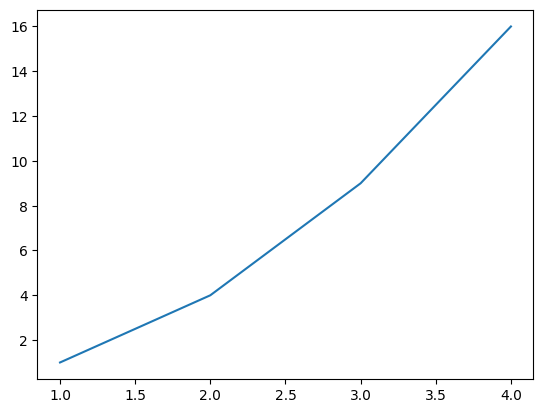

In [86]:
plt.plot([1, 2, 3, 4], [1, 4, 9, 16]) # делаем график из точек таких, что каждые элемент из первого списка - x, а из второго - y

либо в виде отдельный точек:

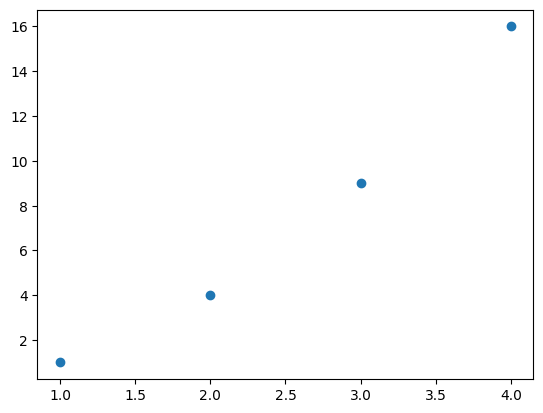

In [87]:
plt.plot([1, 2, 3, 4], [1, 4, 9, 16], 'o') # указываем, что нам нужны именно точки (без линии)

Либо ещё кучей способов.

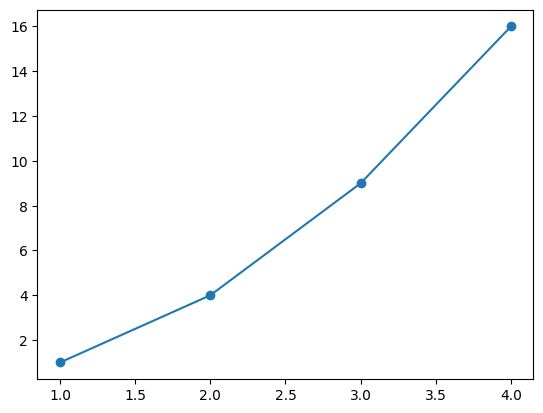

In [88]:
plt.plot([1, 2, 3, 4], [1, 4, 9, 16], '-o') # и точки, и линии

Посмотрим, как `numpy` работает в связке с `matplotlib.pyplot`.
Вообще это всё очень похое на *MATLAB*.

In [89]:
x = np.linspace(-5, 5, 200)
# это массив из 200 элементов, состоящий из равномерно разбитых точек в промежутке [-5; 5]

In [90]:
len(x)

200

In [91]:
x[:10]

array([-5.        , -4.94974874, -4.89949749, -4.84924623, -4.79899497,
       -4.74874372, -4.69849246, -4.64824121, -4.59798995, -4.54773869])

Вот так можно нарисовать параболу:


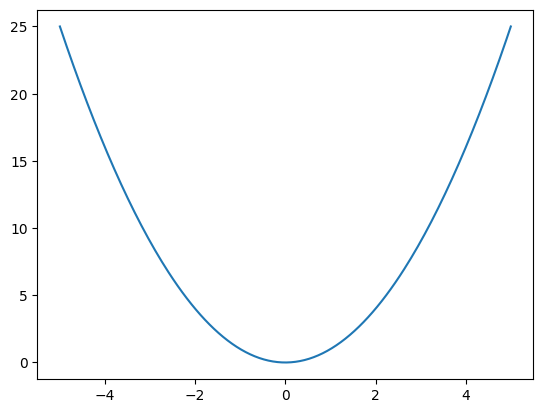

In [92]:
plt.plot(x, x**2) # график параболы

Действительно, `x**2` — это массив, элементами которого являются
квадраты чисел, лежащих в `x` . Значит, построив график, состоящий
из точек, -координаты которых записаны в `x` , а $y$-координаты с
`x**2` , мы построим график функции $y = x^2$.

А вот, например, синусоида:

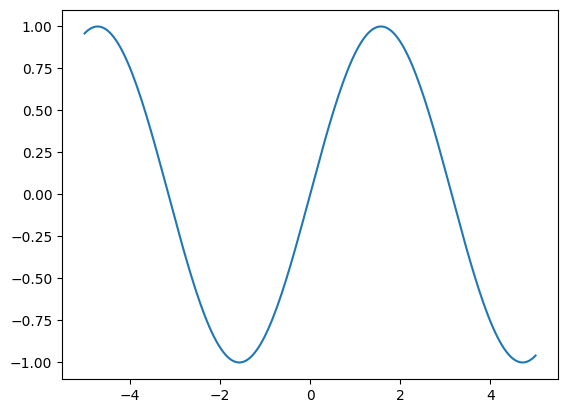

In [93]:
plt.plot(x, np.sin(x)) # график синуса (синусоида)

А вот что-то посложнее:

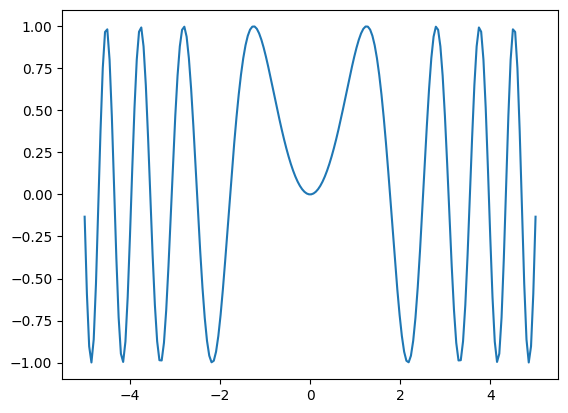

In [94]:
plt.plot(x, np.sin(x**2)) # график синуса от x^2

Вот так можно построить несколько графиков и сделать подписи.

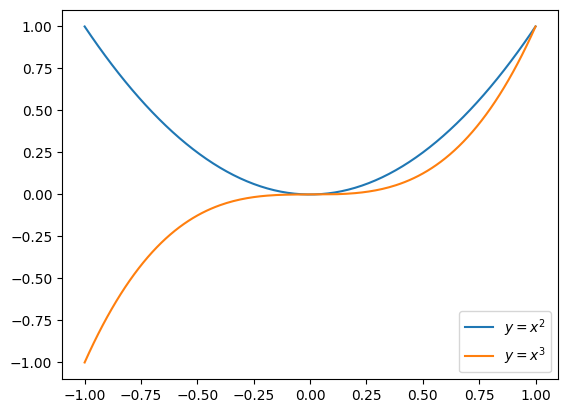

In [95]:
x = np.linspace(-1,1,201)
plt.plot(x,x**2, label = '$y = x^2$') # первая функция (x ** 2) (квадратичная / парабола)
plt.plot(x,x**3, label = '$y = x^3$') # вторая функция (x ** 3) (кубическая)
plt.legend(loc='best')

Знак `$` в `label` используется для того, чтобы записывать формулы
— это делается в [LaTeX](https://en.wikibooks.org/wiki/LaTeX/Mathematics)-нотации и долларами
там обозначается начало и конец формулы. (Кстати, в IPython
Notebook в ячейках типа `Markdown` тоже можно записывать формулы
в LaTeX-нотации.)

Конечно, мы могли бы получить `x` и `y` не в результате вычисления
значений какой-то функции, а откуда-то извне. Возьмём для примера
случайные числа.


In [96]:
x = np.random.random(100)

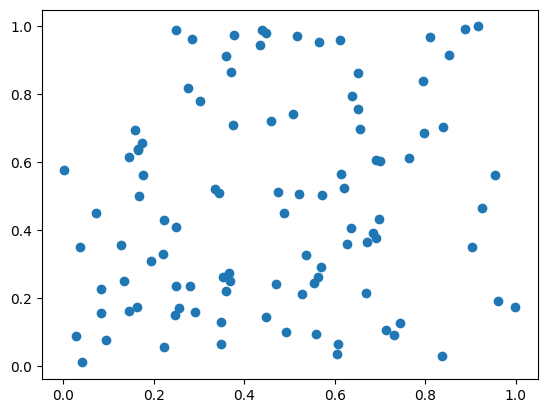

In [97]:
y = np.random.random(100)
plt.plot(x,y, 'o') # график из точек рандомных x и y

Есть и специализированная функция для создания *scatter plot*.


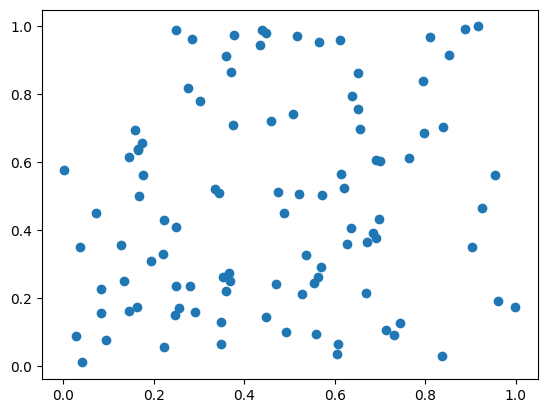

In [98]:
plt.scatter(x,y) # scatter plot

Ещё можно построить гистограмму.

(array([ 8., 12., 12., 13.,  9., 11., 18.,  6.,  5.,  6.]),
 array([0.00269717, 0.10229498, 0.20189279, 0.3014906 , 0.40108842,
        0.50068623, 0.60028404, 0.69988186, 0.79947967, 0.89907748,
        0.99867529]),
 <BarContainer object of 10 artists>)

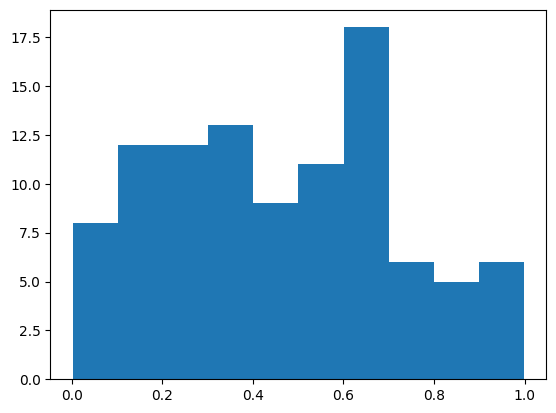

In [99]:
plt.hist(x) # гистограмма из иксов

### Настройка внешнего вида графика
Когда мы строим график для отчёта или презентации, хочется сделать
его красивым и информативным. У matplotlib есть множество
настроек: подписи осей, заголовок, сетка — всё это добавляется парой
строк. Давайте посмотрим, как это делается.


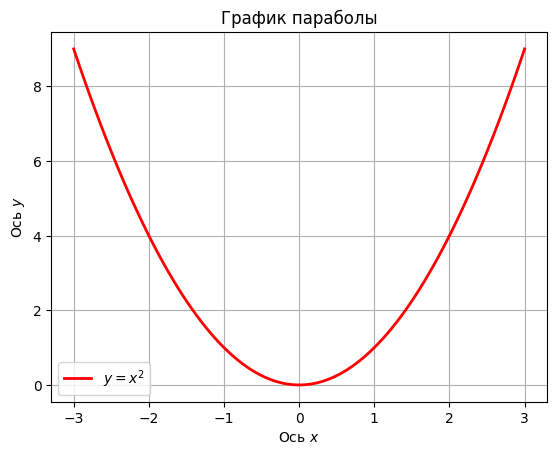

In [100]:
x = np.linspace(-3, 3, 100)
y = x**2
plt.plot(x, y, label='$y = x^2$', color='red', linewidth=2)
plt.xlabel('Ось $x$')        # подпись горизонтальной оси
plt.ylabel('Ось $y$')        # подпись вертикальной оси
plt.title('График параболы') # заголовок
plt.grid(True)               # сетка (True — включить, Fa
plt.legend()                 # показать легенду (label берётся из функции plot())
plt.show()                   # "печатаем" сам график на экран

# можно обойтись и без plt.show(), но тогда выдаст ещё всякую системную информацию (иногда может не вывести график)

Обратите внимание на дополнительные параметры функции `plot` :
`color` задаёт цвет, `linewidth` — толщину линии, `linestyle` —
стиль (например, `'-'` сплошная, `'--'` пунктирная, `':'` точки).
Можно также использовать сокращённые обозначения, как в
MATLAB: `'r--'` — красная пунктирная линия.

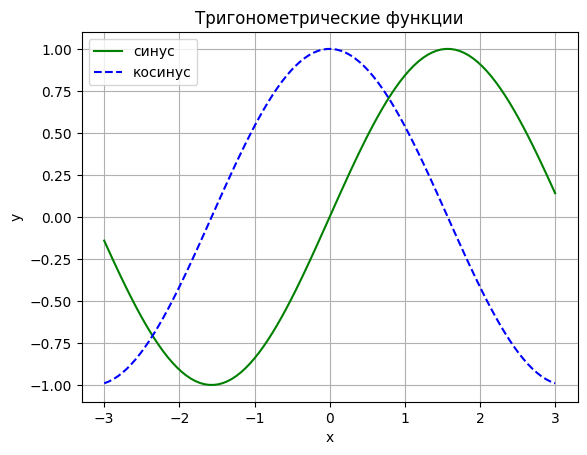

In [101]:
plt.plot(x, np.sin(x), 'g-', label='синус') # стиль линии - зелёная сплошная
plt.plot(x, np.cos(x), 'b--', label='косинус') # стиль линии - синяя пунктирная
plt.xlabel('x')
plt.ylabel('y')
plt.title('Тригонометрические функции')
plt.grid(True)
plt.legend()
plt.show()


### Сохранение графика в файл
Построенный график можно сохранить в файл — например, чтобы
потом вставить в отчёт или презентацию. Для этого используется
функция `savefig` . Она сохраняет текущий график (тот, который был
построен последним) в указанный файл. Формат определяется
расширением: `.png`, `.jpg`, `.pdf`, `.svg` и другие.

График сохранён в файл 'gaussian.png'
И в 'gaussian.pdf'


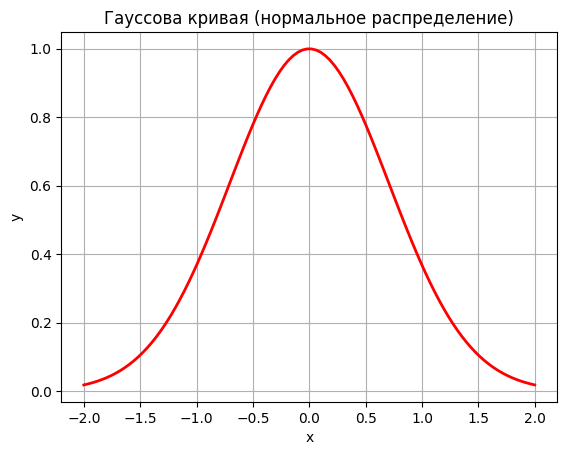

In [102]:
x = np.linspace(-2, 2, 100)
plt.plot(x, np.exp(-x**2), 'r-', linewidth=2)
plt.xlabel('x')
plt.ylabel('y')
plt.title('Гауссова кривая (нормальное распределение)')
plt.grid(True)
# Сохраняем график в .png
plt.savefig('gaussian.png', dpi=150) # dpi — разрешение в точках на дюйм (dots per inch)
print("График сохранён в файл 'gaussian.png'")
# Можно сохранить и в векторном формате (.pdf) (удобно для статей)
plt.savefig('gaussian.pdf')
print("И в 'gaussian.pdf'")
plt.show()

**Важно:** `savefig` нужно вызывать до `plt.show()`, потому что
`show()` часто очищает график. Если вызвать после — можно
получить пустую картинку.


### Несколько графиков на одной картинке (subplots)
Часто бывает нужно сравнить несколько графиков, разместив их рядом
или друг над другом. Для этого в `matplotlib` есть функция `subplots` .
Она создаёт сетку из графиков (осей) и возвращает фигуру и массив
осей, с которыми можно работать как с отдельными графиками.

<>:12: SyntaxWarning: invalid escape sequence '\s'
<>:12: SyntaxWarning: invalid escape sequence '\s'
C:\Users\Komp\AppData\Local\Temp\ipykernel_24256\1536636936.py:12: SyntaxWarning: invalid escape sequence '\s'
  axes[1].set_title('$y = \sin(x)$')


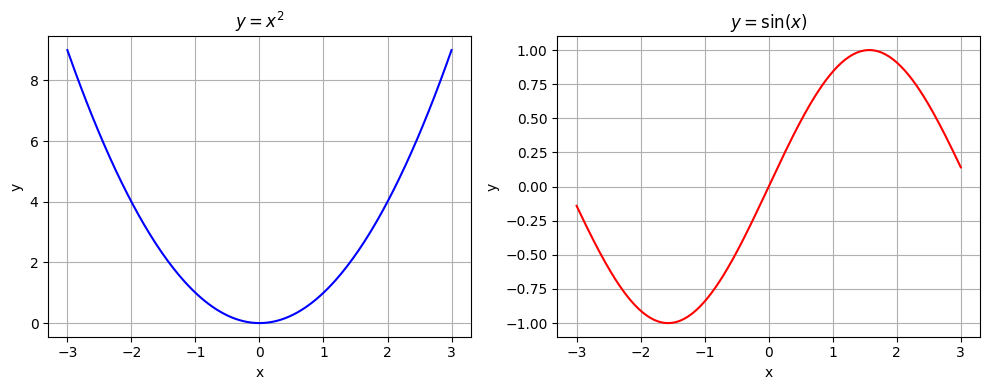

In [103]:
x = np.linspace(-3, 3, 200)
# Создаём фигуру с 1 строкой и 2 столбцами графиков
fig, axes = plt.subplots(1, 2, figsize=(10, 4)) # figsize - задаёт размеры холста
# Первый график (левый)
axes[0].plot(x, x**2, 'b-')
axes[0].set_title('$y = x^2$')
axes[0].set_xlabel('x')
axes[0].set_ylabel('y')
axes[0].grid(True)
# Второй график (правый)
axes[1].plot(x, np.sin(x), 'r-')
axes[1].set_title('$y = \sin(x)$')
axes[1].set_xlabel('x')
axes[1].set_ylabel('y')
axes[1].grid(True)
# Автоматически подгоняем расположение, чтобы ничего не нал
plt.tight_layout()
plt.show()

Можно сделать и вертикальное расположение: `subplots(2, 1)` — 2
строки, 1 столбец. Или даже сетку 2×2:


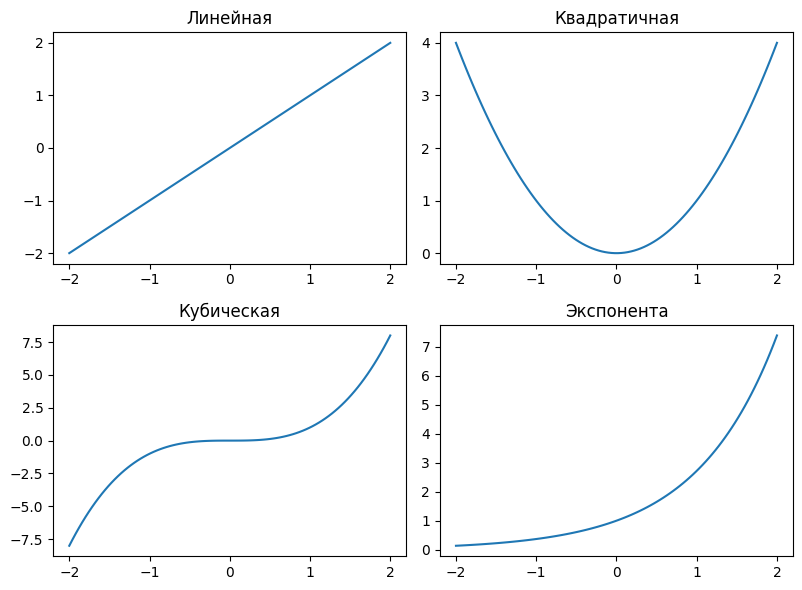

In [104]:
fig, axes = plt.subplots(2, 2, figsize=(8, 6))
# axes[0,0] — верхний левый, axes[0,1] — верхний правый и т.д.
x = np.linspace(-2, 2, 100)
axes[0,0].plot(x, x)
axes[0,0].set_title('Линейная')
axes[0,1].plot(x, x**2)
axes[0,1].set_title('Квадратичная')
axes[1,0].plot(x, x**3)
axes[1,0].set_title('Кубическая')
axes[1,1].plot(x, np.exp(x))
axes[1,1].set_title('Экспонента')
plt.tight_layout()
plt.show()

Обратите внимание: раньше мы использовали `plt.plot(...)` , а
теперь — `axes[0].plot(...)` . Это разные интерфейсы: первый
(pyplot) автоматически рисует на «текущем» графике, второй
(объектно-ориентированный) даёт полный контроль над тем, где
именно что рисовать. Для сложных картинок второй способ удобнее.

Можно строить трёхмерные картинки, но тут уже нужна магия и я не
буду вдаваться в детали.

In [105]:
import matplotlib.pyplot as plt
from mpl_toolkits.mplot3d import Axes3D
fig = plt.figure()

<Figure size 640x480 with 0 Axes>

In [106]:
%matplotlib inline

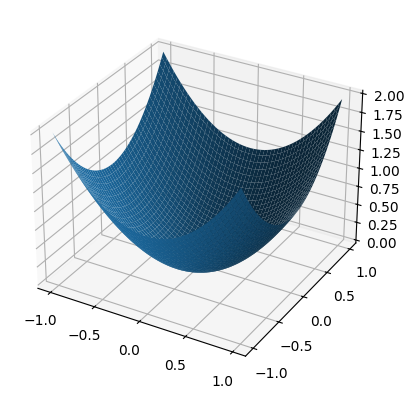

In [107]:
x,y = np.mgrid[-1:1:0.01, -1:1:0.01]
ax = fig.add_subplot(111, projection='3d')
ax.plot_surface(x,y,x**2+y**2)
fig


Наконец, можно строить интерактивные картинки!


In [3]:
from ipywidgets import interact, interactive, fixed
import ipywidgets as widgets
import numpy as np
import matplotlib.pyplot as plt

ModuleNotFoundError: No module named 'numpy'

In [4]:
%matplotlib inline

ModuleNotFoundError: No module named 'matplotlib'

In [5]:
def plot_pic(a, b):
    x = np.linspace(-3,3,200)
    plt.plot(x, np.sin(x*a+b))
    plt.show()

In [ ]:
interact(plot_pic, a=[0, 3, 0.1], b=[0, 3, 0.1])

interactive(children=(Dropdown(description='a', options=(0, 3, 0.1), value=0), Dropdown(description='b', optio…

<function __main__.plot_pic(a, b)>

Функция `interact` создаёт несколько бегунков и позволяет с их
помощью задавать параметры у функции (в данном случае
`plot_pic` ), которая строит график.

> Эта картинка не будет интерактивной при просмотре IPython Notebook, но если вы скачаете его и запустите у себя на компьютере, то там будет.

Ещё `interact` можно вызывать так:

In [6]:
@interact(a=[0, 3, 0.1], b=[0, 3, 0.1])
def plot_pic(a, b):
    x = np.linspace(-3,3,200)
    plt.plot(x, np.sin(x*a+b))
    plt.show()

interactive(children=(Dropdown(description='a', options=(0, 3, 0.1), value=0), Dropdown(description='b', optio…

<hr color="#b700ff">

# Практические задачи

1. Создайте массив из 20 случайных чисел от 0 до 1 с помощью
`np.random.random`. Найдите его среднее, сумму и максимальный
элемент.

In [113]:
my_arr = array(np.random.random(20))
print(my_arr)
print("Среднее значение: ", my_arr.mean())
print("Сумма всех элем.: ", my_arr.sum())
print("Максимальный элемент: ", my_arr.max())

[0.26756573 0.74705819 0.81175892 0.64377884 0.45830761 0.1496513
 0.63672184 0.03035475 0.1766412  0.07898056 0.19291712 0.5480513
 0.43252954 0.62768484 0.44016568 0.77310825 0.29692443 0.25099438
 0.99315648 0.93761426]
Среднее значение:  0.47469826026241424
Сумма всех элем.:  9.493965205248285
Максимальный элемент:  0.9931564762347586


2. Создайте одномерный массив чисел от 0 до 99 (с помощью
`np.arange` ), а затем преобразуйте его в матрицу 10×10 с помощью
`reshape` .

In [114]:
arr = np.arange(100)
print(arr)

matrix = arr.reshape(10, 10)
print(matrix)

[ 0  1  2  3  4  5  6  7  8  9 10 11 12 13 14 15 16 17 18 19 20 21 22 23
 24 25 26 27 28 29 30 31 32 33 34 35 36 37 38 39 40 41 42 43 44 45 46 47
 48 49 50 51 52 53 54 55 56 57 58 59 60 61 62 63 64 65 66 67 68 69 70 71
 72 73 74 75 76 77 78 79 80 81 82 83 84 85 86 87 88 89 90 91 92 93 94 95
 96 97 98 99]
[[ 0  1  2  3  4  5  6  7  8  9]
 [10 11 12 13 14 15 16 17 18 19]
 [20 21 22 23 24 25 26 27 28 29]
 [30 31 32 33 34 35 36 37 38 39]
 [40 41 42 43 44 45 46 47 48 49]
 [50 51 52 53 54 55 56 57 58 59]
 [60 61 62 63 64 65 66 67 68 69]
 [70 71 72 73 74 75 76 77 78 79]
 [80 81 82 83 84 85 86 87 88 89]
 [90 91 92 93 94 95 96 97 98 99]]


3. Дан массив `[1, 2, 3, 4, 5, 6, 7, 8, 9, 10]`. С помощью
индексации выберите все чётные элементы (нечётные индексы) и
замените их на 0.

In [115]:
arr = np.arange(1, 11)
print(arr, type(arr))

arr[1::2] = 0
print(arr)

[ 1  2  3  4  5  6  7  8  9 10] <class 'numpy.ndarray'>
[1 0 3 0 5 0 7 0 9 0]


4. Создайте два массива: `a = np.array([1, 2, 3])` и `b = np.array([10, 20, 30])`. Выполните сложение, умножение и
возведение `a` в степень `b` (поэлементно).

In [116]:
a = np.array([1, 2, 3])
b = np.array([10, 20, 30])

print("Сумма a+b:", a+b)
print("Произведение a*b:", a*b)
print("Возведение в степень a^b:", a**b)
print("Все операции проведены поэлементно!")

Сумма a+b: [11 22 33]
Произведение a*b: [10 40 90]
Возведение в степень a^b: [              1         1048576 205891132094649]
Все операции проведены поэлементно!


5. Дан массив `[10, 20, np.nan, 40, np.nan, 60]`. Замените все
пропуски ( `nan` ) на среднее значение остальных элементов.

In [117]:
arr = np.array([10, 20, np.nan, 40, np.nan, 60])

arr[np.isnan(arr)] = np.nanmean(arr)
print("Сред.зн:", np.nanmean(arr))
print("Итог:", arr)

Сред.зн: 32.5
Итог: [10.  20.  32.5 40.  32.5 60. ]


6. Постройте график функции `y = x^3 - 2*x` на отрезке от `-3` до `3`.
Добавьте подписи осей, заголовок и сетку.

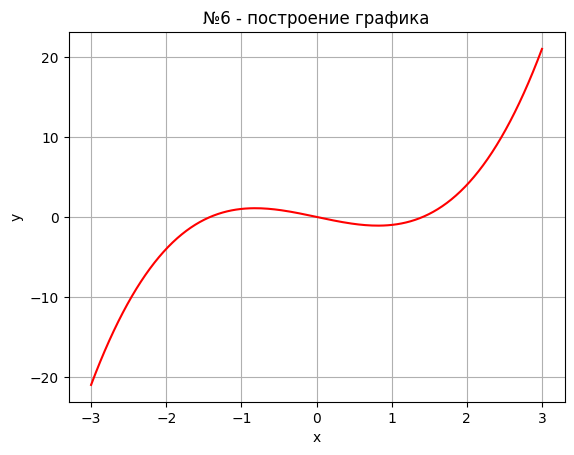

In [118]:
x = np.linspace(-3, 3, 200)
plt.plot(x, (x**3)-2*x, color='red', label='$y = x^3 - 2x$')
plt.xlabel('x')
plt.ylabel('y')
plt.title('№6 - построение графика')
plt.grid(True)
plt.show()

7. На одном графике постройте две кривые: `y = sin(x)` и `y = cos(x)` разными цветами и стилями линий (например, синяя
сплошная и красная пунктирная). Добавьте легенду.

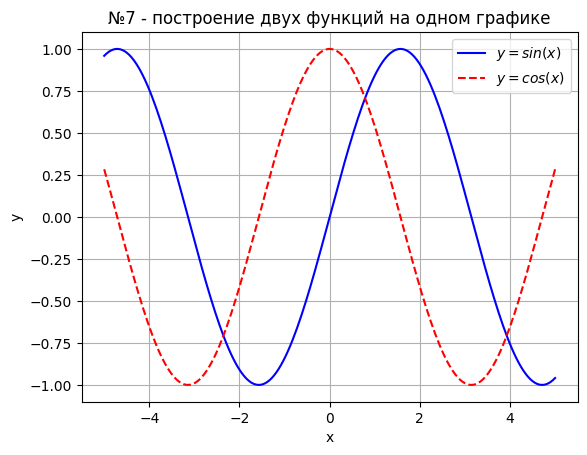

In [119]:
x = np.linspace(-5, 5, 200)
plt.plot(x, np.sin(x), 'b-', label='$y = sin(x)$')
plt.plot(x, np.cos(x), 'r--', label='$y = cos(x)$')
plt.legend()
plt.grid(True)
plt.xlabel('x')
plt.ylabel('y')
plt.title("№7 - построение двух функций на одном графике")
plt.show()

8. Сгенерируйте 200 случайных точек с координатами `x` и `y` (каждая
от `0` до `10`) и постройте `scatter plot` (диаграмму рассеяния).

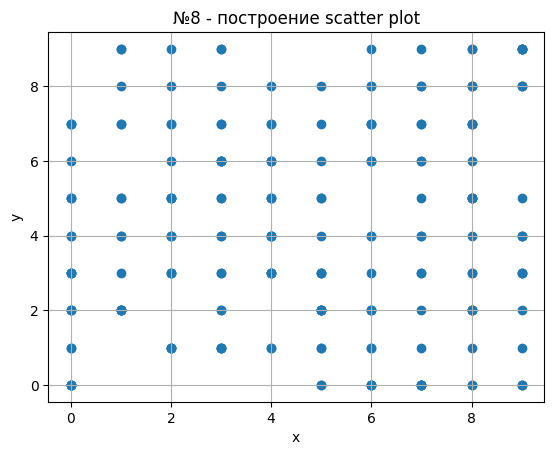

In [120]:
x = np.random.randint(0, 10, 200)
y = np.random.randint(0, 10, 200)

plt.scatter(x, y)
plt.title("№8 - построение scatter plot")
plt.grid(True)
plt.xlabel('x')
plt.ylabel('y')
plt.show()

9. Постройте гистограмму для 1000 случайных чисел, распределённых
нормально ( `np.random.randn(1000)` ). Установите количество
столбцов (bins) равным 30.

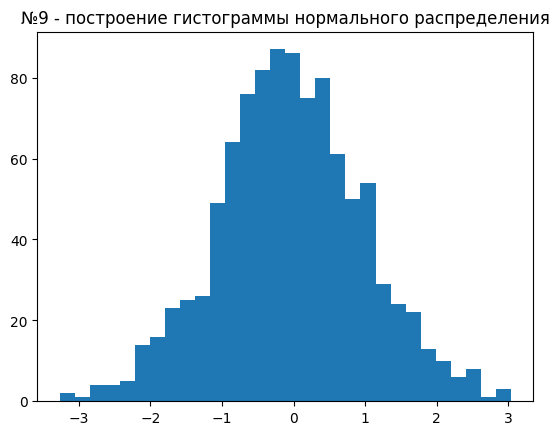

In [121]:
x = np.random.randn(1000)
plt.hist(x, bins=30)
plt.title("№9 - построение гистограммы нормального распределения")
plt.show()

10. Создайте `figure` с 2 подграфиками (1 строка, 2 столбца). На первом
подграфике — график `y = x^2` , на втором — график `y = sqrt(x)`
для x от 0 до 10.

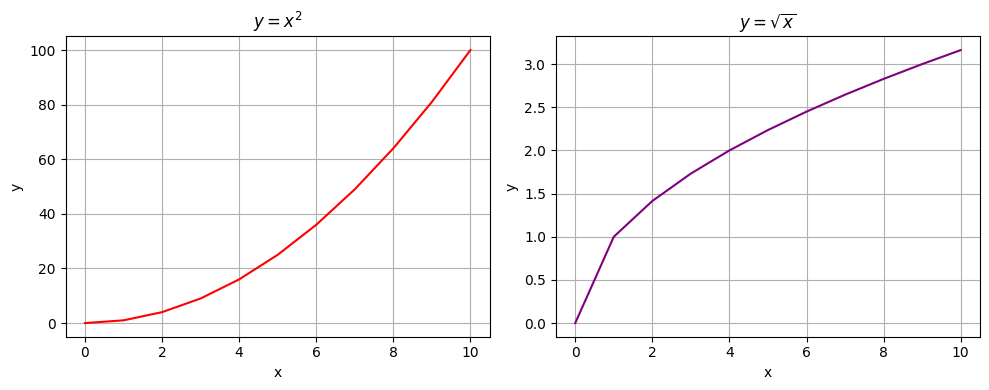

In [122]:
figure, axes = plt.subplots(1, 2, figsize=(10, 4))
x = np.arange(11)

axes[0].plot(x, x**2, color='red')
axes[0].set_xlabel('x')
axes[0].set_ylabel('y')
axes[0].set_title('$y = x^2$')
axes[0].grid(True)

axes[1].plot(x, np.sqrt(x), color='purple')
axes[1].set_xlabel('x')
axes[1].set_ylabel('y')
axes[1].set_title('$y = \\sqrt{x}$')
axes[1].grid(True)

plt.tight_layout()
plt.show()

<hr color="#b700ff">